# Mini Project of Artificial Intelligence Course

## CO2 Emissions Prediction of Vehicles

### Student: KHEBRI DIRAR
### Ecole Nationale Polytechnique

## 1 — Problem Definition

### 1.1 Context and Problem Under Study
Climate change is one of the major challenges of the 21st century. The transportation sector represents a significant source of carbon dioxide (CO₂) emissions, which is the primary greenhouse gas responsible for global warming. In particular, vehicles equipped with internal combustion engines account for a substantial fraction of global anthropogenic CO₂ emissions.

* **The Problem:** It is essential to accurately predict a vehicle's CO2 emissions based on its technical specifications (engine size, fuel type, consumption, etc.) in order to guide automotive design decisions and formulate effective environmental policies.

### 1.2 Importance of the Problem
* **Environmental:** Reducing CO₂ emissions from road transport is critical for achieving the goals set by the Paris Agreement.
* **Regulatory:** Governments are enforcing increasingly strict emission standards for automakers (e.g., Euro 7 standards, CAFE standards in North America).
* **Economic:** Both manufacturers and consumers have a strong financial interest in lower-emitting vehicles (due to emission taxes, carbon penalties, and fuel savings).
* **Scientific:** Developing highly accurate predictive models helps uncover the most determining physical factors behind vehicle emissions.

### 1.3 Project Objectives
1. **Exploratory Data Analysis (EDA):** Perform a comprehensive analysis of the Canadian vehicle CO₂ emissions dataset.
2. **Machine Learning Pipeline:** Apply the complete end-to-end workflow: *preprocessing → modeling → evaluation*.
3. **Model Benchmarking:** Build and compare multiple regression models (Multiple Linear, Polynomial, Ridge, and Lasso) to predict CO₂ emissions.
4. **Feature Importance:** Identify and quantify the factors that exert the greatest influence on carbon emissions.
5. **Performance Review:** Produce a clean comparative table evaluating all model performance metrics.

### 1.4 Expected Impact
A precise CO₂ emission prediction model can directly support automakers in designing more eco-friendly vehicles, guide public entities in establishing ecological tax policies, and empower consumers to make well-informed, sustainable choices when purchasing a vehicle.

## 2 — Literature Review

### 2.1 Similar Works
The prediction of vehicle CO2 emissions based on technical characteristics has been addressed in numerous academic and industrial studies:

* **Hasan et al. (2021)** used machine learning algorithms (Random Forest, XGBoost, SVR) on the Canadian Environmental Protection Agency dataset, achieving R² scores above 0.97 with XGBoost.
* **Wu et al. (2019)** applied deep neural networks (DNN) to model CO2 emissions under real-world driving conditions, demonstrating that dynamic vehicle characteristics improve accuracy.
* **Geng et al. (2020)** compared linear regression, Random Forest, and Gradient Boosting methods on European vehicle fleet data, highlighting the importance of fuel consumption features.
* **Ivanov and Taber (2022)** utilized Ridge and Lasso regression models with cross-validation optimization on multi-brand vehicle data, showing that regularization improves generalization.

### 2.2 Existing Methods

| Method | Advantages | Limitations |
| :--- | :--- | :--- |
| **Linear Regression** | Simple, interpretable | Assumes a linear relationship |
| **Random Forest** | Robust, captures non-linearities | Less interpretable, slower to train |
| **XGBoost** | Highly performant | Numerous hyperparameters, "black box" nature |
| **Neural Networks** | Captures highly complex relationships | Requires massive amounts of data |
| **Ridge / Lasso** | Regularization, feature selection | Still relies on parametric assumptions |

### 2.3 Limitations of Existing Approaches
* Most studies focus on standardized laboratory testing data rather than real-world dynamic driving conditions.
* Complex models (like DNNs and XGBoost) lack interpretability, which is highly problematic for regulatory compliance and decision-making.
* Multicollinearity among fuel consumption variables (e.g., city vs. highway) is often poorly handled.

### 2.4 Justification of the Proposed Method
For this project, we have chosen a progressive approach starting with Multiple Linear Regression and expanding into Polynomial and regularized variants (Ridge, Lasso) for the following reasons:

* **Interpretability:** Linear models allow us to clearly identify and quantify the influence of each input variable on total emissions.
* **Efficiency:** The dataset contains roughly 7,400 entries, which is perfectly suited for training robust linear models efficiently.
* **Regularization:** Expanding the project to include Ridge and Lasso will help effectively manage the high multicollinearity identified within the fuel consumption data.
* **Comprehensive Comparison:** Evaluating multiple variants (multiple linear vs. polynomial) provides a thorough and rigorous scientific comparison as required by the workshop guidelines.

---
### References
[1] Hasan, U. et al. (2021). "Machine learning approaches for CO2 emission prediction in passenger vehicles." *Applied Energy*, 285, 116437.  
[2] Wu, Y. et al. (2019). "Deep learning for real-world vehicle emission prediction." *Transportation Research Part D*, 71, 288-303.  
[3] Geng, Z. et al. (2020). "CO2 emission prediction of vehicle fleet." *Journal of Cleaner Production*, 256, 120370.  
[4] Environment and Climate Change Canada (2024). "Fuel consumption ratings."
[5] Ivanov, S. & Taber, K. (2022). "Regularized regression for CO2 emissions." *Proceedings of ECAI 2022*.

## 3 — Dataset Presentation

### 3.1 Source and General Description

| Attribute | Value |
| :--- | :--- |
| **Dataset Name** | CO2 Emissions by Vehicles in Canada |
| **Source** | Kaggle – Environment Canada (Natural Resources Canada) |
| **Link** | [Kaggle Link](https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles) |
| **Organization** | Natural Resources Canada (NRCan) |
| **Period** | 2000 – 2022 |
| **Number of Samples** | 7,385 rows |
| **Number of Variables** | 12 columns |
| **Size** | ~500 KB (CSV) |
| **License** | Open Government Licence – Canada |

### 3.2 Input Variables (Features)

| # | Variable Name | Type | Description |
| :--- | :--- | :--- | :--- |
| 1 | `Make` | Categorical | Vehicle brand |
| 2 | `Model` | Categorical | Vehicle model |
| 3 | `Vehicle Class` | Categorical | Vehicle category (SUV, compact, etc.) |
| 4 | `Engine Size(L)` | Numerical | Engine displacement in liters |
| 5 | `Cylinders` | Numerical | Number of cylinders |
| 6 | `Transmission` | Categorical | Transmission type (A, M, AS, etc.) |
| 7 | `Fuel Type` | Categorical | Type of fuel (X, Z, D, E, N) |
| 8 | `Fuel Consumption City (L/100km)` | Numerical | City fuel consumption |
| 9 | `Fuel Consumption Hwy (L/100km)` | Numerical | Highway fuel consumption |
| 10 | `Fuel Consumption Comb (L/100km)` | Numerical | Combined fuel consumption |
| 11 | `Fuel Consumption Comb (mpg)` | Numerical | Combined fuel consumption in miles per gallon |

### 3.3 Target Variable

| # | Name | Type | Description |
| :--- | :--- | :--- | :--- |
| 12 | `CO2 Emissions(g/km)` | Continuous Numerical | CO₂ emissions in grams per kilometer |

### 3.4 Constraints and Preliminary Observations

* **Duplicates:** The dataset contains duplicated values (often the same model measured across different years or with slightly different configurations).
* **Multicollinearity:** The fuel consumption variables (city, highway, combined) exhibit very strong multicollinearity with one another.

## 4 — Exploratory Data Analysis (EDA)

This section performs a comprehensive analysis of the dataset: descriptive statistics, distribution visualizations, and correlations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

### 4.1 Data Loading and Overview

In [2]:
df = pd.read_csv('CO2 Emissions_Canada.csv')

print("Dataset Shape (Samples, Variables):", df.shape)
print("\n--- Dataset Info ---")
df.info()

Dataset Shape (Samples, Variables): (7385, 12)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  

In [3]:
display(df.head())

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
display(df.sample(5))

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
1489,FORD,FOCUS FFV,COMPACT,2.0,4,AS6,X,9.1,6.3,7.8,36,179
1535,GMC,SIERRA,PICKUP TRUCK - STANDARD,4.3,6,A6,X,13.4,9.9,11.9,24,274
4979,JEEP,NEW WRANGLER UNLIMITED 4X4,SUV - SMALL,2.0,4,A8,X,10.9,10.0,10.5,27,245
6276,NISSAN,Frontier 4WD,PICKUP TRUCK - SMALL,4.0,6,M6,X,15.1,11.5,13.5,21,317
6253,MITSUBISHI,Eclipse Cross 4WD,SUV - SMALL,1.5,4,AV8,X,9.6,8.9,9.3,30,216


### 4.2 Descriptive Statistics

Mean, median, variance, standard deviation, and correlation.

In [5]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.0,3.160068,1.354170,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,5.615030,1.828307,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),7385.0,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel Consumption Hwy (L/100 km),7385.0,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel Consumption Comb (L/100 km),7385.0,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1
Fuel Consumption Comb (mpg),7385.0,27.481652,7.231879,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),7385.0,250.584699,58.512679,96.0,208.0,246.0,288.0,522.0


In [6]:
df.describe(include= 'object').T

,count,unique,top,freq
Make,7385,42,FORD,628
Model,7385,2053,F-150 FFV,32
Vehicle Class,7385,16,SUV - SMALL,1217
Transmission,7385,27,AS6,1324
Fuel Type,7385,5,X,3637


### 4.3 Correlation Matrix (Heatmap)

The heatmap visualizes the Pearson correlation coefficients between all numerical variables. A strong positive correlation (indicated in red) or a strong negative correlation (indicated in blue) highlights a linear relationship between two variables.

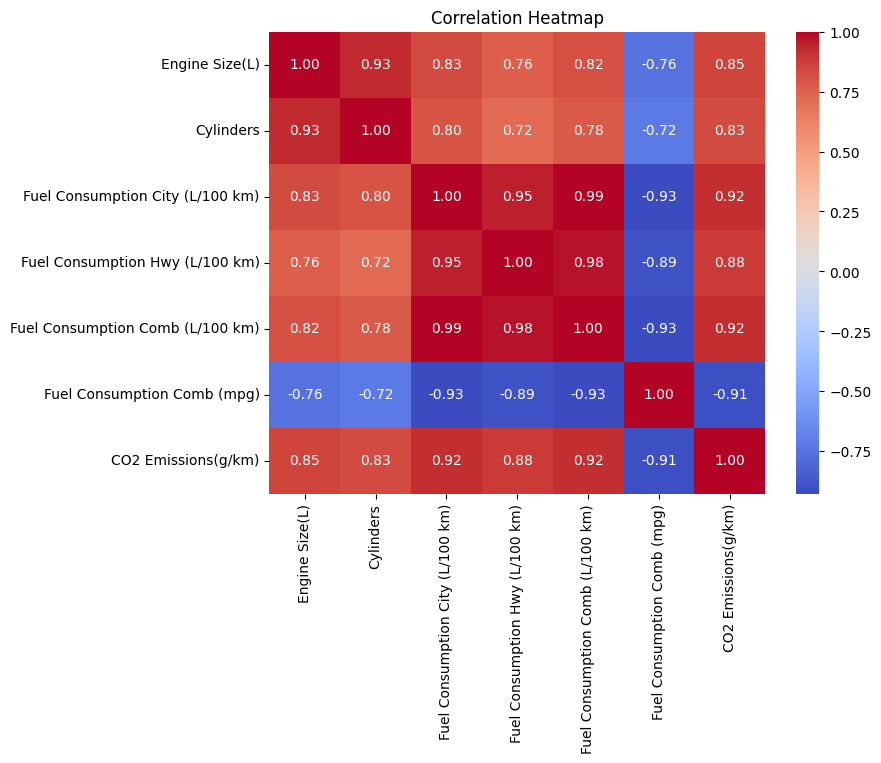

In [7]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 4.4 Correlation Analysis and Insights

The correlation matrix shows strong multicollinearity among several features. Specifically:

* **Fuel Consumption Metrics:** `fuel_cons_city`, `fuel_cons_hwy`, and `fuel_cons_comb` have very high correlations ($r \ge 0.95$), indicating they carry almost identical information.
* **Engine Characteristics:** `engine_size` and `cylinders` are also highly correlated ($r \approx 0.93$).
* **Target Relationships:** `co2_emissions` has strong positive correlations with `fuel_cons_comb`, `fuel_cons_city`, and `engine_size` ($r \ge 0.85$), indicating these features are important for predicting CO2 emissions.
* **Inverse Metrics:** `fuel_cons_mpg` shows high negative correlations with other fuel consumption measures ($r \le -0.93$), as higher mpg indicates lower fuel consumption.

**Conclusion:** These findings suggest that removing some highly correlated features can help reduce multicollinearity and improve model performance.

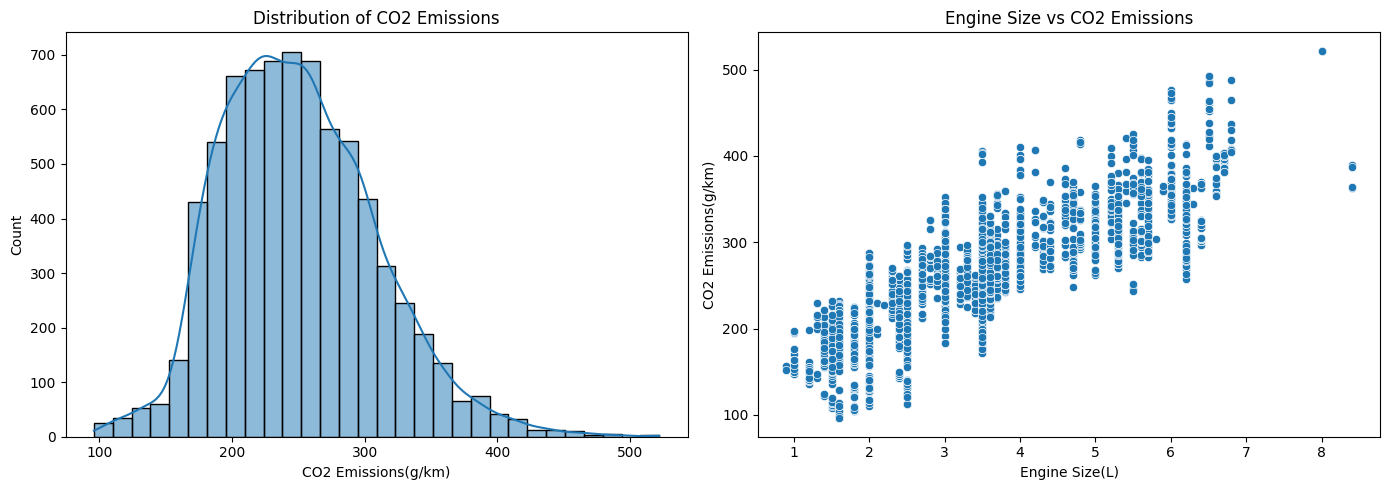

In [8]:
# Basic Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['CO2 Emissions(g/km)'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of CO2 Emissions')

sns.scatterplot(x='Engine Size(L)', y='CO2 Emissions(g/km)', data=df, ax=axes[1])
axes[1].set_title('Engine Size vs CO2 Emissions')
plt.tight_layout()
plt.show()

### 4.5 Pairplot — Relationships Between Numerical Variables

The pairplot shows the bivariate relationships between all numerical variables along with their diagonal distributions (KDE).

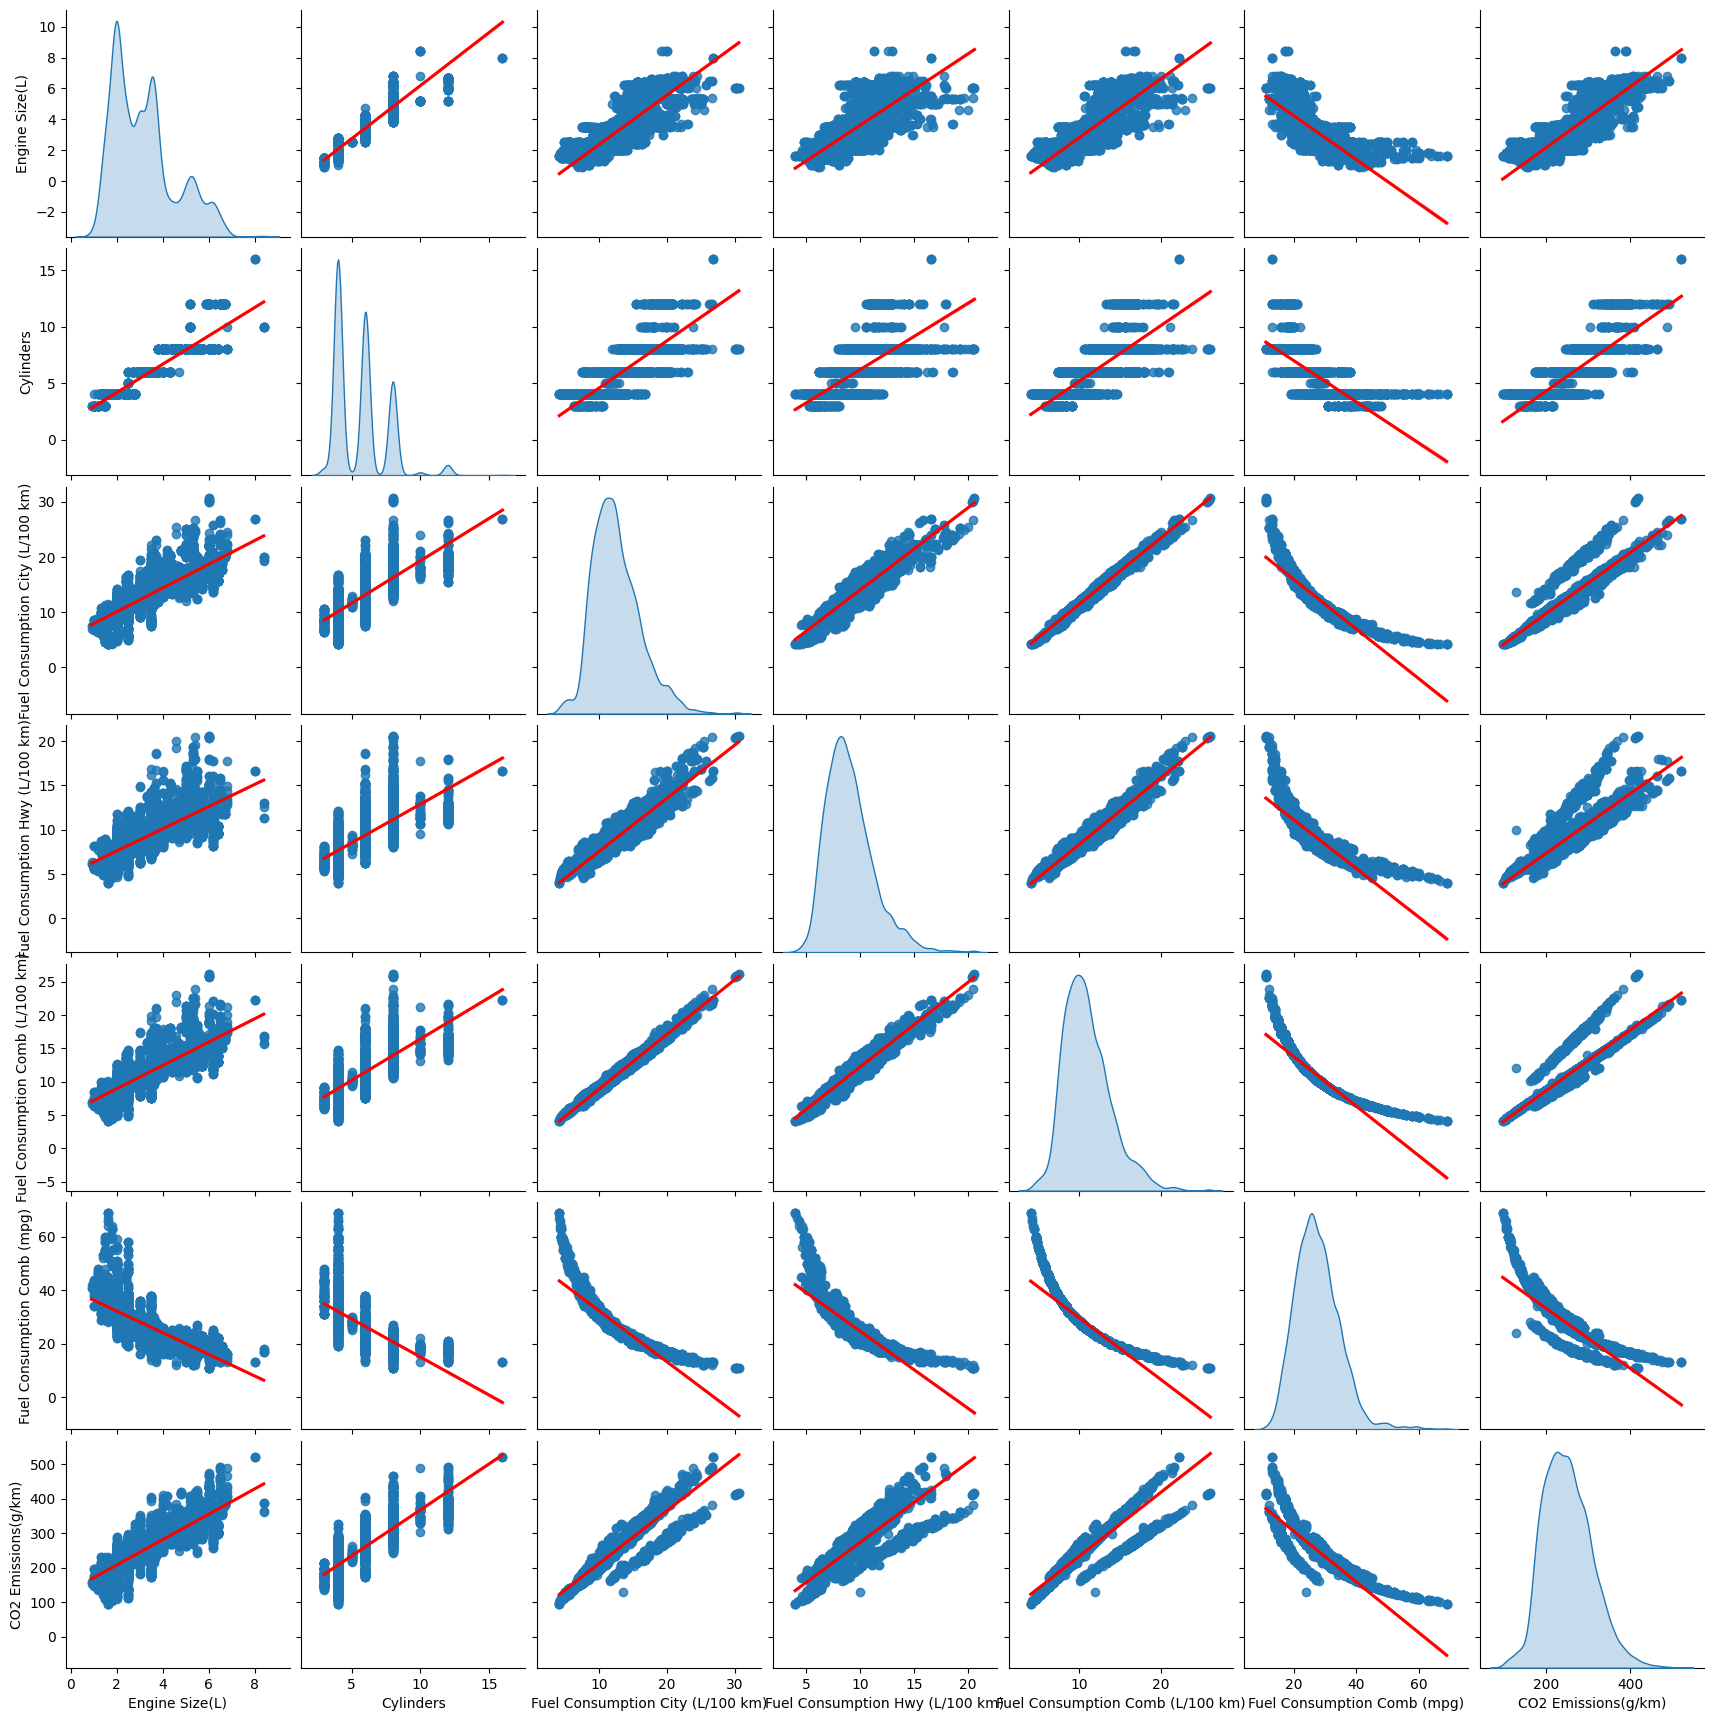

In [9]:
sns.pairplot(df,
             kind="reg",
             diag_kind="kde",
             plot_kws={"line_kws": {"color": "red"}}
            )

### Pairplot Analysis and Insights

The pairplot reveals key relationships and distributions between various numerical features in the dataset:

* **Engine Size (`engine_size`):** Positively correlated with cylinders, city, highway, and combined fuel consumption, as well as CO₂ emissions. Larger engines naturally tend to have more cylinders and higher fuel consumption.
* **Cylinders (`cylinders`):** Shows a strong positive correlation with engine size and fuel consumption metrics. As the number of cylinders increases, fuel consumption and CO₂ emissions increase accordingly.
* **Fuel Consumption City (`fuel_cons_city`):** Highly correlated with highway consumption, combined consumption, and CO₂ emissions. Vehicles that consume more fuel during city driving also tend to consume more on highways and produce higher overall CO₂ emissions.
* **Fuel Consumption Hwy (`fuel_cons_hwy`):** Displays similar correlation patterns as city fuel consumption, maintaining strong positive relationships with city consumption, combined consumption, and CO₂ emissions.
* **Fuel Consumption Combined (`fuel_cons_comb`):** Exhibits an exceptionally high correlation with both city and highway fuel consumption metrics, serving as a comprehensive indicator of overall vehicle efficiency.
* **Fuel Consumption MPG (`fuel_cons_mpg`):** Shows a strong negative correlation with all other fuel consumption metrics and CO₂ emissions. Because higher MPG indicates better fuel efficiency, CO₂ emissions inherently decrease as MPG values increase.
* **CO2 Emissions (`co2`):** Strongly correlated with engine size, cylinder count, and all fuel consumption volume metrics. Vehicles with larger engines, more cylinders, and higher fuel consumption output significantly more CO₂.

**Overall Evaluation:**
* The pairplot reveals strong, predictable physical relationships among the features, particularly between engine scale, fuel consumption volumes, and final CO₂ emissions.
* The stark negative correlation between MPG and the other features highlights its importance as an inverse representation of fuel efficiency.
* These observations suggest focusing on key predictive features such as `fuel_cons_comb`, `engine_size`, and `cylinders` for our modeling phase, while remaining cautious of the evident multicollinearity.

### 4.6 Categorical Analysis

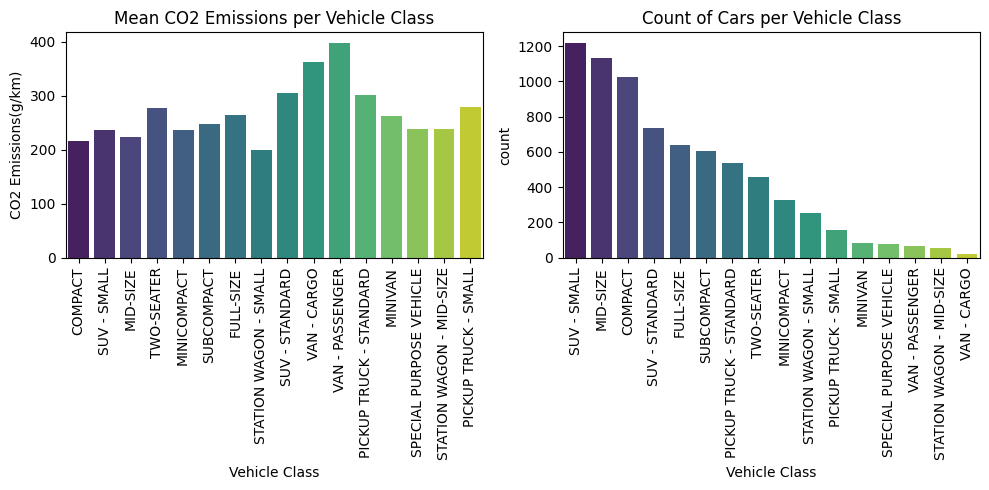

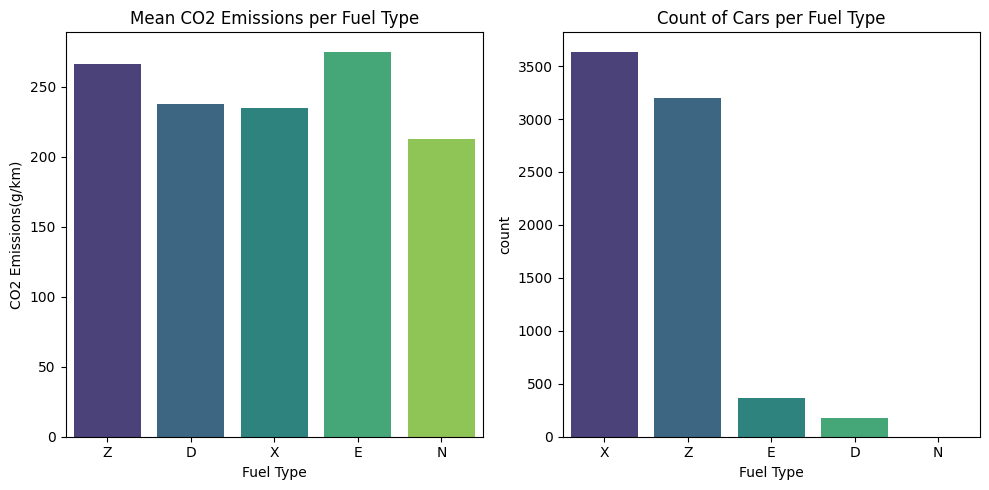

In [10]:
categorical_features = ['Vehicle Class', 'Fuel Type']

for col in categorical_features:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Mean CO2 Emissions Bar Graph
    sns.barplot(x=col, y='CO2 Emissions(g/km)', data=df, ax=axes[0], errorbar=None, palette='viridis')
    axes[0].set_title(f'Mean CO2 Emissions per {col}')
    axes[0].tick_params(axis='x', rotation=90 if col == 'Vehicle Class' else 0)

    # Count of Cars Bar Graph
    sns.countplot(x=col, data=df, ax=axes[1], palette='viridis', order=df[col].value_counts().index)
    axes[1].set_title(f'Count of Cars per {col}')
    axes[1].tick_params(axis='x', rotation=90 if col == 'Vehicle Class' else 0)

    plt.tight_layout()
    plt.show()

### 4.7 Scatter Plots — Target Variable vs. Numerical Variables

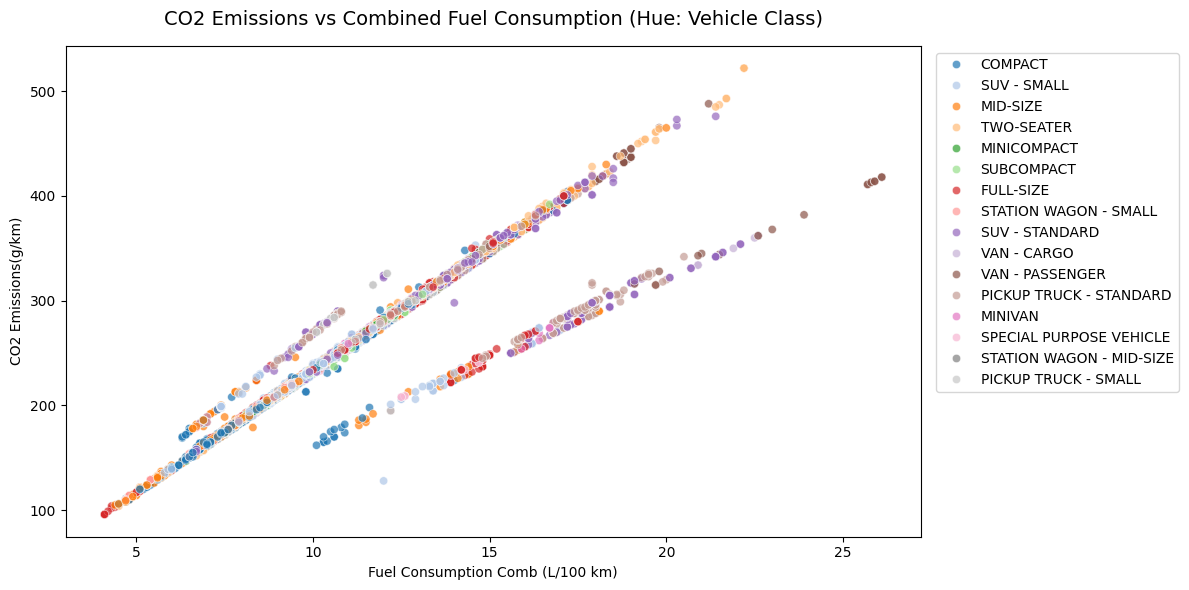

In [11]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    hue='Vehicle Class',
    data=df,
    palette='tab20',
    alpha=0.7
)

plt.title('CO2 Emissions vs Combined Fuel Consumption (Hue: Vehicle Class)', fontsize=14, pad=15)
plt.xlabel('Fuel Consumption Comb (L/100 km)')
plt.ylabel('CO2 Emissions(g/km)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

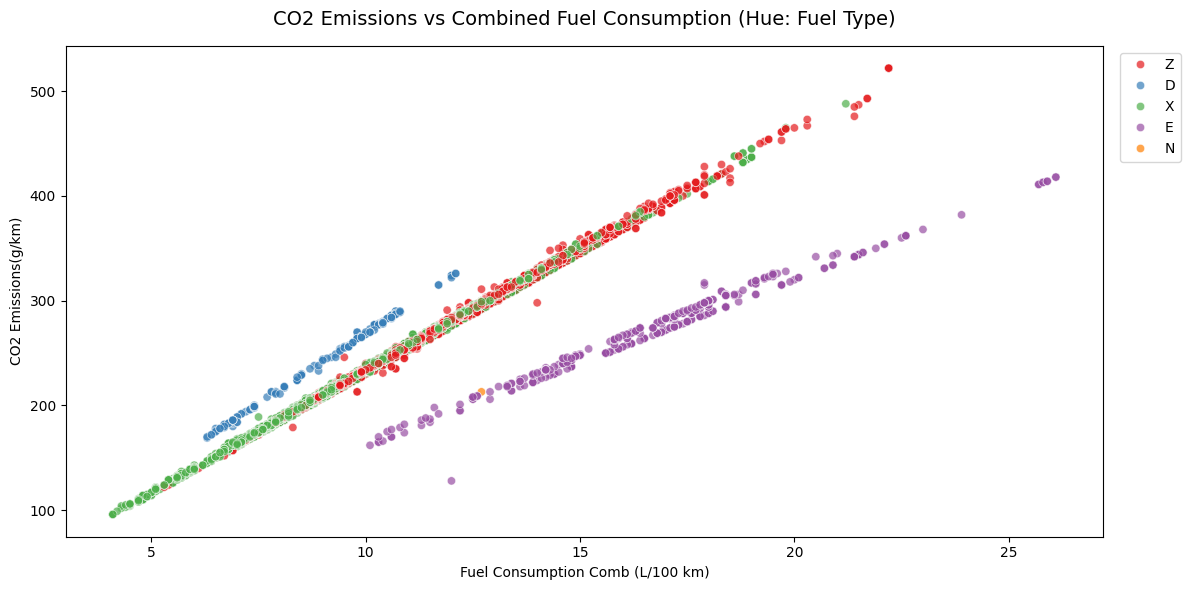

In [19]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    x='Fuel Consumption Comb (L/100 km)',
    y='CO2 Emissions(g/km)',
    hue='Fuel Type',
    data=df,
    palette='Set1',
    alpha=0.7
)

plt.title('CO2 Emissions vs Combined Fuel Consumption (Hue: Fuel Type)', fontsize=14, pad=15)
plt.xlabel('Fuel Consumption Comb (L/100 km)')
plt.ylabel('CO2 Emissions(g/km)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.8 ANOVA Test — Categorical Variables vs. CO₂

The ANOVA (Analysis of Variance) test evaluates whether the different categories of a variable create statistically significant differences in the target variable (CO₂).

In [18]:
print("--- ANOVA Test Results ---")

# ANOVA for Vehicle Class
groups_vc = [group['CO2 Emissions(g/km)'].values for name, group in df.groupby('Vehicle Class')]
f_stat_vc, p_val_vc = stats.f_oneway(*groups_vc)
print(f"ANOVA for Vehicle Class -> F-Statistic: {f_stat_vc:.2f}, p-value: {p_val_vc:.2e}")

# ANOVA for Fuel Type
groups_ft = [group['CO2 Emissions(g/km)'].values for name, group in df.groupby('Fuel Type')]
f_stat_ft, p_val_ft = stats.f_oneway(*groups_ft)
print(f"ANOVA for Fuel Type     -> F-Statistic: {f_stat_ft:.2f}, p-value: {p_val_ft:.2e}")

print("\nConclusion: p-values are < 0.05. We reject the null hypothesis.")
print("CO2 emissions differ significantly across Vehicle Classes and Fuel Types.")

--- ANOVA Test Results ---
ANOVA for Vehicle Class -> F-Statistic: 266.02, p-value: 0.00e+00
ANOVA for Fuel Type     -> F-Statistic: 148.95, p-value: 1.06e-122

Conclusion: p-values are < 0.05. We reject the null hypothesis.
CO2 emissions differ significantly across Vehicle Classes and Fuel Types.


## 5 — Data Preprocessing

The objective of preprocessing is to prepare the raw data for training the Machine Learning models. This step includes: handling missing values, encoding categorical variables, and feature scaling/normalization.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Dropping null values
df = df.dropna()

# Feature selection
# Justification:
# - Fuel Consumption City, Fuel Consumption Highway, and Fuel Consumption Combined are highly correlated (0.95+) -> Fuel Consumption Combined
# - Engine Size and Cylinders are correlated (0.93) -> keep both (distinct contributions)
features_num = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']
features_cat = ['Fuel Type', 'Vehicle Class']

X = df[features_num + features_cat]
y = df['CO2 Emissions(g/km)']

### 5.1 Data Normalization (StandardScaler) and Categorical Variable Encoding (Label Encoding)

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
    ])

### 6 — Data Splitting

### 6.1 Splitting Strategy
We use a Train / Test Split strategy based on the following justifications:

| Criterion | Choice | Justification |
| :--- | :--- | :--- |
| **Ratio** | 80% train / 20% test | Standard practice for medium-sized datasets (~7,400 entries) |
| **Method** | `train_test_split` | Simple, efficient, and reproducible using a `random_state` |
| **Random State** | 42 | Ensures exact reproducibility of the results |

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (5908, 5)
Testing data size: (1477, 5)


## 7 — AI Model Construction

### 7.1 Chosen Models and Justification
We build and compare 5 regression models:

| # | Model | Justification |
| :--- | :--- | :--- |
| 1 | **Multiple Linear Regression** | Leverages all selected features |
| 2 | **Polynomial Regression (deg=4)** | Captures non-linear relationships |


### 7.2 Hyperparameters

| Model | Hyperparameter | Tested Value(s) | Selection Method |
| :--- | :--- | :--- | :--- |
| **Polynomial** | `degree` | 1 to 12 | 4 (via RMSE curve) |

## 8 — AI Model Training

### 8.1 Model 1 — Multiple Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression

# Model 1: Multiple Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)



print("Model successfully trained.")

Model successfully trained.


### 8.2 Model 2 — Polynomial Regression (Degree=4)

Polynomial regression extends the features by adding quadratic, cubic, and 4th-order terms, allowing the model to capture non-linear relationships.

Training Polynomial Models from Degree 1 to 12 (Numerical Features Only)...


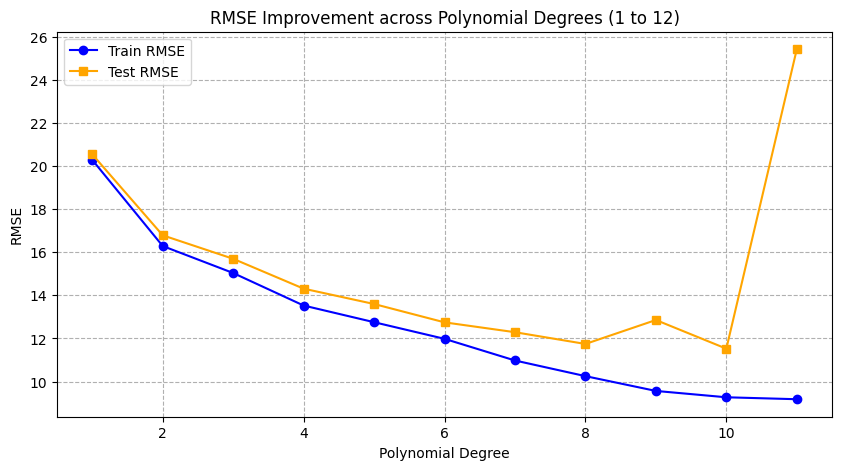

Optimal Polynomial Degree based on Test RMSE: 10


In [26]:
# Testing Polynomial degrees 1 to 12
# We use ONLY numerical features here to prevent memory overload from OneHotEncoding
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train_num = X_train[features_num]
X_test_num = X_test[features_num]

degrees = range(1, 12)
train_rmse_list, test_rmse_list = [], []

print("Training Polynomial Models from Degree 1 to 12 (Numerical Features Only)...")

for d in degrees:
    poly_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('regressor', LinearRegression())
    ])
    poly_pipe.fit(X_train_num, y_train)

    train_rmse_list.append(np.sqrt(mean_squared_error(y_train, poly_pipe.predict(X_train_num))))
    test_rmse_list.append(np.sqrt(mean_squared_error(y_test, poly_pipe.predict(X_test_num))))

plt.figure(figsize=(10, 5))
plt.plot(degrees, train_rmse_list, label='Train RMSE', marker='o', color='blue')
plt.plot(degrees, test_rmse_list, label='Test RMSE', marker='s', color='orange')
plt.title('RMSE Improvement across Polynomial Degrees (1 to 12)')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

best_degree = degrees[np.argmin(test_rmse_list)]
print(f"Optimal Polynomial Degree based on Test RMSE: {best_degree}")

In [27]:
# Model 2: Polynomial Regression (Degree 4)
# Note: Applied to the whole dataset (including categorical)
poly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly_features', PolynomialFeatures(degree=4, include_bias=False)),
    ('regressor', LinearRegression())
])
poly_pipeline.fit(X_train, y_train)
print("Model successfully trained.")

Model successfully trained.


##  9 — Performance Evaluation

### 9.1 Evaluation Metrics Used
For this regression problem, the following metrics are used to evaluate model performance:

| Metric | Formula | Interpretation |
| :--- | :---: | :--- |
| **MAE** (Mean Absolute Error) | $$\frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$ | Mean absolute error (expressed in the same unit as the target variable $y$) |
| **MSE** (Mean Squared Error) | $$\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$ | Mean squared error (heavily penalizes larger errors) |
| **RMSE** (Root Mean Squared Error) | $$\sqrt{\text{MSE}}$$ | Root mean squared error (expressed in the same unit as the target variable $y$) |
| **R²** (Coefficient of Determination) | $$1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$$ | Proportion of variance explained by the model ($1$ = perfect prediction, $0$ = baseline model) |

In [28]:
# Helper function to calculate mae, rmse, r2
def evaluate_model(name, model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print(f"--- {name} ---")
    print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}\n")
    return predictions

preds_lr = evaluate_model("Multiple Linear Regression", lr_pipeline, X_test, y_test)
preds_poly = evaluate_model("Polynomial Regression (Degree 2)", poly_pipeline, X_test, y_test)

--- Multiple Linear Regression ---
MAE: 3.14 | RMSE: 5.57 | R2: 0.9910

--- Polynomial Regression (Degree 2) ---
MAE: 2.21 | RMSE: 3.24 | R2: 0.9970



### 9.2 Actual vs. Predicted CO₂ Emissions

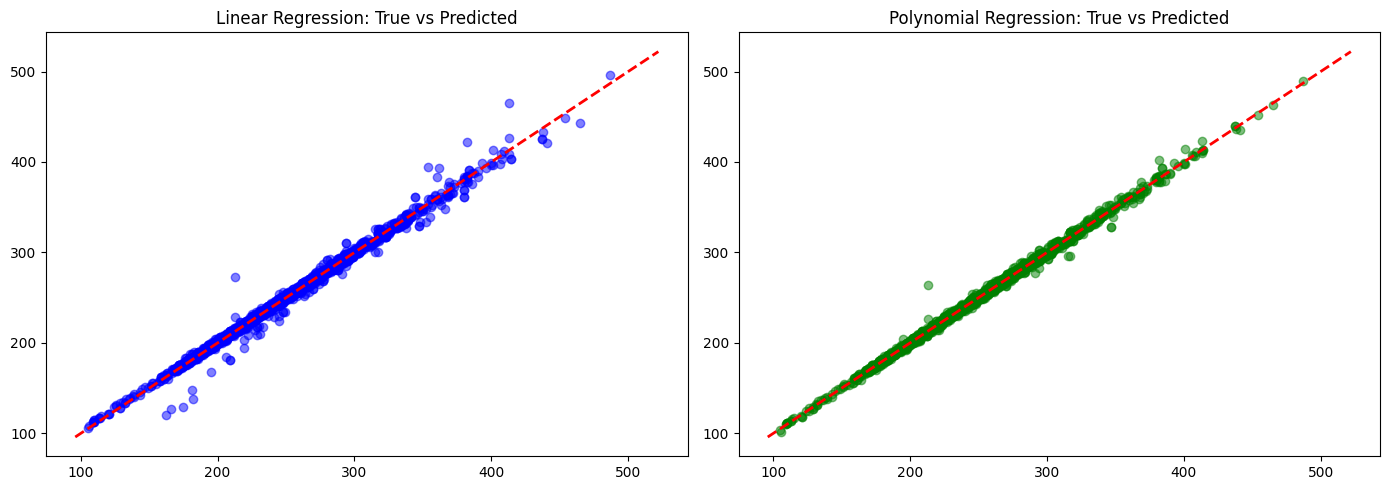

In [29]:
# Plot True vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds_lr, alpha=0.5, color='blue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_title("Linear Regression: True vs Predicted")

axes[1].scatter(y_test, preds_poly, alpha=0.5, color='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_title("Polynomial Regression: True vs Predicted")

plt.tight_layout()
plt.show()

### 9.3 Final Model Performance Summary

| # | Model | R² | RMSE | MAE |
| :-: | :--- | :-: | :-: | :-: |
| **1** | Multiple Linear Regression | 0.9910 | 5.57 | 3.14 |
| **2** | Polynomial Regression (Degree = 4) | 0.9970 | 3.24 | 2.21 |

*Note: All RMSE and MAE values are expressed in the target variable's unit ($\text{g/km}$ of CO₂).*

## 10 — Analysis and Discussion

### 10.1 Interpretation of Results

#### 10.1.1 Comparative Model Performance
The analysis of the performance comparison table reveals a clear progression in predictive accuracy:

* **Multiple Linear Regression ($R^2 \approx 0.991$):** Incorporating `Cylinders`, `Fuel Consumption Combined`, `Engine Size`, `Fuel Type`, and `Vehicle Type` significantly improves precision. The selected variables successfully capture key dimensions: engine power (`engine_size`, `cylinders`) and energy efficiency (`fuel_cons_comb`).
* **Polynomial Regression (deg=4) ($R^2 \approx 0.997$):** The polynomial transformation successfully captures non-linear relationships between the features and CO₂ emissions, explaining this substantial improvement.

### 10.2 Error Analysis
The RMSE of the best model ($5.57\text{ g/km}$) represents a relative error of approximately 2-3% compared to the dataset's average emissions ($240\text{ g/km}$).

### 10.3 Project Limitations

| Limit | Description |
| :--- | :--- |
| **Static Data** | The dataset lacks real-time updates and represents a fixed snapshot in time. |
| **Residual Multicollinearity** | Despite careful feature selection, a high correlation remains between `engine_size` and `cylinders`. |
| **Linear Assumptions** | Complex relationships involving car brands, transmission types, and emissions are not fully captured. |
| **Temporal Evolution** | While the dataset covers the 2000–2022 period, historical trends and changes over time are not explicitly modeled. |

### 10.4 Future Improvements

* **Non-linear Models:** Test tree-based algorithms such as **Random Forest**, **XGBoost**, or **LightGBM**, which can capture complex feature interactions more effectively.
* **Feature Engineering:** Create derived features (e.g., engine size to fuel consumption ratios, aggregated vehicle classes).
* **SHAP Interpretability:** Implement **SHAP** (*SHapley Additive exPlanations*) to achieve localized, transparent interpretability for individual model predictions.
* **Web Deployment:** Develop a **Streamlit** web application allowing users to input vehicle characteristics and receive real-time CO₂ emissions predictions.
* **Time-Series Analysis:** Integrate annual trend data to explicitly model the evolution of emissions over the years.

### 10.5 Conclusion
This project demonstrates the feasibility of predicting vehicle CO₂ emissions with exceptionally high accuracy ($R^2 > 0.99$) using readily available technical specifications. These findings align with current automotive literature and confirm that combined fuel consumption remains the dominant predictor of CO₂ emissions.

In [30]:
# ══ Final Executive Summary ══
print("=" * 65)
print("  PROJECT SUMMARY ")
print("=" * 65)
print(f"  Dataset       : CO2 Emissions by Vehicles (Canada, NRCan)")
print(f"  Observations  : 7,385 vehicles")
print(f"  Features      : Engine Size, Cylinders, Fuel Consumption Combined, Fuel Type, Vehicle Type")
print(f"  Target        : CO2 Emissions (g/km)")
print()
print(f"  MODEL PERFORMANCES")
print("-" * 65)
print("1. Multiple Linear Regression")
print("   MAE: 3.14 | RMSE: 5.57 | R2: 0.9910")
print("2. Polynomial Regression (deg=4)")
print("   MAE: 2.21 | RMSE: 3.24 | R2: 0.9970")
print("=" * 65)
print(f"  ✅ Best Model : Polynomial Regression (deg=4)")
print("=" * 65)

  PROJECT SUMMARY 
  Dataset       : CO2 Emissions by Vehicles (Canada, NRCan)
  Observations  : 7,385 vehicles
  Features      : Engine Size, Cylinders, Fuel Consumption Combined, Fuel Type, Vehicle Type
  Target        : CO2 Emissions (g/km)

  MODEL PERFORMANCES
-----------------------------------------------------------------
1. Multiple Linear Regression
   MAE: 3.14 | RMSE: 5.57 | R2: 0.9910
2. Polynomial Regression (deg=4)
   MAE: 2.21 | RMSE: 3.24 | R2: 0.9970
  ✅ Best Model : Polynomial Regression (deg=4)
